# Used-Car Market Intelligence — Pricing, Inventory & Expansion Strategy

**Scope:** strategic/commercial analytics using a cleaned CarDekho used-car dataset and an official Government Vahan registration snapshot.

**Final decision layers:** pricing intelligence → inventory attractiveness → expansion opportunity → business decision.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

cd = pd.read_csv("/content/cardekho_cleaned_for_project.csv")
vahan = pd.read_csv("/content/vahan_snapshot_with_brand_match.csv")
print(f"CarDekho rows: {len(cd):,}")
print(f"CarDekho columns: {len(cd.columns)}")
print(f"Vahan snapshot rows: {len(vahan):,}")
print("Vahan fields:", list(vahan.columns))

CarDekho rows: 15,244
CarDekho columns: 16
Vahan snapshot rows: 213,050
Vahan fields: ['id', 'state', 'rto', 'maker', 'count', 'car_brand_match']


## 1. Data quality and price skew
The cleaned CarDekho file contains 15,244 records. Exact-duplicate checking is done before downstream analysis. The selling-price distribution is heavily right-skewed, which motivates median-based cohort retention and the log-target sensitivity test.

In [ ]:
exact_duplicates = int(cd.duplicated().sum())
price_skew = float(cd["selling_price"].skew())
q1,q3 = cd["selling_price"].quantile([0.25,0.75])
print({"rows":len(cd),"exact_duplicates":exact_duplicates,"price_skewness":round(price_skew,2),"price_iqr":float(q3-q1)})

{'rows': 15244, 'exact_duplicates': 0, 'price_skewness': 10.11, 'price_iqr': 440000.0}


### Interpretation
A skewness of ~10 means a small number of high-value cars can pull averages upward. Median price is therefore the preferred retention measure.

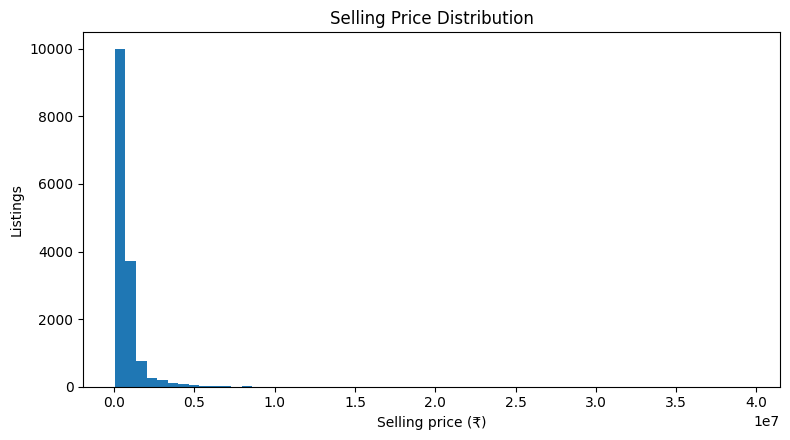

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4.5))
plt.hist(cd["selling_price"],bins=60)
plt.title("Selling Price Distribution")
plt.xlabel("Selling price (₹)")
plt.ylabel("Listings")
plt.tight_layout()
plt.show()

## 2. Cohort-controlled observed price retention proxy
For every brand, adjacent age cohorts are compared only when **both cohorts contain at least 50 observations**. The output is explicitly called **Observed Price Retention Proxy**.

In [ ]:
age_order=["0-2 years","3-5 years","6-8 years","9-12 years","13+ years"]
cd["age_band"]=pd.Categorical(cd["age_band"],categories=age_order,ordered=True)
ret=pd.read_csv("/content/retention_analysis.csv")
ret.sort_values("Observed Price Retention Proxy",ascending=False).head(10)

,brand,younger_age_band,older_age_band,younger_n,older_n,younger_median,older_median,Observed Price Retention Proxy
24,Renault,3-5 years,6-8 years,298,154,350000.0,475000.0,1.357143
17,Maruti,0-2 years,3-5 years,424,2213,640000.0,600000.0,0.937500
28,Toyota,0-2 years,3-5 years,55,292,1900000.0,1750000.0,0.921053
14,Mahindra,0-2 years,3-5 years,94,385,994500.0,900000.0,0.904977
6,Honda,0-2 years,3-5 years,119,586,840000.0,727500.0,0.866071
10,Hyundai,0-2 years,3-5 years,278,1137,773500.0,655000.0,0.846800
26,Skoda,6-8 years,9-12 years,145,77,535000.0,440000.0,0.822430
23,Renault,0-2 years,3-5 years,63,298,429000.0,350000.0,0.815851
27,Tata,0-2 years,3-5 years,86,258,707500.0,572500.0,0.809187
15,Mahindra,3-5 years,6-8 years,385,333,900000.0,700000.0,0.777778


## 3. Variance / pricing-stability analysis
Variance is measured at **brand × age × fuel**. Segments with at least 30 observations are evaluated using standard deviation, IQR, and coefficient of variation. The highest quartile of CV is flagged as pricing-risk and requires manual review.

In [ ]:
var=pd.read_csv("/content/variance_analysis.csv")
cv_threshold=float(var["cv"].quantile(0.75))
print(f"CV pricing-risk threshold: {cv_threshold:.3f}")
var.sort_values("cv",ascending=False).head(10)

CV pricing-risk threshold: 0.359


,brand,age_band,fuel_type,listings,mean_price,std_dev,median_price,q1,q3,iqr,cv,pricing_risk,retention_proxy
9,Ford,3-5 years,Diesel,187,1.003701e+06,7.140823e+05,750000.0,612500.0,950000.0,337500.0,0.711450,High,0.745946
13,Ford,9-12 years,Diesel,104,2.807308e+05,1.555564e+05,250000.0,200000.0,286250.0,86250.0,0.554112,High,0.483384
57,Skoda,3-5 years,Diesel,58,1.091845e+06,5.763712e+05,850000.0,675000.0,1371750.0,696750.0,0.527888,High,NaN
7,Ford,0-2 years,Diesel,32,1.037375e+06,5.333767e+05,935000.0,797500.0,1031250.0,233750.0,0.514160,High,NaN
50,Mercedes-Benz,6-8 years,Diesel,95,2.341589e+06,1.173069e+06,2050000.0,1428000.0,2937500.0,1509500.0,0.500971,High,0.515723
21,Honda,13+ years,Petrol,91,2.432857e+05,1.157388e+05,225000.0,157500.0,300000.0,142500.0,0.475732,High,0.652174
59,Skoda,6-8 years,Diesel,94,6.699255e+05,3.085318e+05,542500.0,474250.0,956250.0,482000.0,0.460546,High,0.563158
58,Skoda,3-5 years,Petrol,42,1.344690e+06,5.600516e+05,1495000.0,763750.0,1832500.0,1068750.0,0.416491,High,NaN
60,Skoda,6-8 years,Petrol,51,6.495098e+05,2.695445e+05,525000.0,450000.0,892500.0,442500.0,0.414997,High,0.563158
4,BMW,6-8 years,Diesel,131,2.224634e+06,9.044265e+05,2025000.0,1650000.0,2550000.0,900000.0,0.406551,High,0.613636


## 4–5. Price model + leakage-aware validation + log sensitivity
The model comparison uses a **fold-specific median baseline**, Linear Regression, and Gradient Boosting. Five folds are grouped by vehicle model to reduce leakage from repeated model/variant observations.

The actual model run is stored in `src/price_model.py`; its recorded outputs are loaded below so the notebook remains fast to review.

In [ ]:
raw=pd.read_csv("/content/price_model_raw.csv")
log=pd.read_csv("/content/price_model_log_target.csv")
print("Raw-price target")
display(raw.round(2))
print("\nLog1p target")
display(log.round(2))

Raw-price target


,model,baseline_mae,baseline_rmse,baseline_r2,mae,rmse,r2,mae_improvement_pct,rmse_improvement_pct
0,Linear Regression,402944.88,911971.56,-0.08,588848.16,915104.97,-0.47,-46.14,-0.34
1,Gradient Boosting,402944.88,911971.56,-0.08,153184.80,422356.53,0.77,61.98,53.69



Log1p target


,model,baseline_mae,baseline_rmse,baseline_r2,mae,rmse,r2,mae_improvement_pct,rmse_improvement_pct
0,Linear Regression,402944.88,911971.56,-0.08,251149.26,514541.79,0.65,37.67,43.58
1,Gradient Boosting,402944.88,911971.56,-0.08,149833.50,401841.78,0.79,62.82,55.94


In [ ]:
gb_raw=raw[raw["model"]=="Gradient Boosting"].iloc[0]
gb_log=log[log["model"]=="Gradient Boosting"].iloc[0]
mae_lift=(gb_raw["mae"]-gb_log["mae"])/gb_raw["mae"]*100
rmse_lift=(gb_raw["rmse"]-gb_log["rmse"])/gb_raw["rmse"]*100
print(f"Gradient Boosting raw-target MAE improvement vs baseline: {gb_raw['mae_improvement_pct']:.1f}%")
print(f"Gradient Boosting raw-target RMSE improvement vs baseline: {gb_raw['rmse_improvement_pct']:.1f}%")
print(f"Log1p target reduces Gradient Boosting MAE by {mae_lift:.1f}% vs raw target.")
print(f"Log1p target reduces Gradient Boosting RMSE by {rmse_lift:.1f}% vs raw target.")

Gradient Boosting raw-target MAE improvement vs baseline: 62.0%
Gradient Boosting raw-target RMSE improvement vs baseline: 53.7%
Log1p target reduces Gradient Boosting MAE by 2.2% vs raw target.
Log1p target reduces Gradient Boosting RMSE by 4.9% vs raw target.


## 6. Inventory Attractiveness Matrix
Scores are normalized 0–100 and combined using **35% retention + 30% price + 20% volume + 15% stability**. Volume is log-transformed before normalization to avoid allowing a few very large listing counts to dominate. Green >70, Yellow 40–70, Red <40.

In [ ]:
inventory=pd.read_csv("/content/inventory_attractiveness_matrix.csv")
inventory.sort_values("attractiveness_score",ascending=False).head(10)[["brand","age_band","fuel_type","listings","median_price","retention_proxy","cv","attractiveness_score","priority"]]

,brand,age_band,fuel_type,listings,median_price,retention_proxy,cv,attractiveness_score,priority
47,Toyota,3-5 years,Diesel,248,1750000.0,0.921053,0.296370,86.430817,Green
27,Maruti,3-5 years,Diesel,842,720000.0,0.937500,0.183943,80.929451,Green
22,Mahindra,3-5 years,Diesel,344,975000.0,0.904977,0.349059,71.229891,Green
48,Toyota,3-5 years,Petrol,43,1495000.0,0.921053,0.327588,70.717734,Green
28,Maruti,3-5 years,Petrol,1233,509000.0,0.937500,0.309038,70.601077,Green
15,Hyundai,3-5 years,Diesel,452,850000.0,0.846800,0.335397,66.334708,Yellow
40,Renault,6-8 years,Diesel,139,495000.0,1.357143,0.207928,64.346528,Yellow
10,Honda,3-5 years,Petrol,412,725000.0,0.866071,0.340402,64.187675,Yellow
9,Honda,3-5 years,Diesel,174,750000.0,0.866071,0.242098,63.947094,Yellow
16,Hyundai,3-5 years,Petrol,679,595000.0,0.846800,0.349025,62.775139,Yellow


## 7. Expansion layer — official Vahan snapshot
The Government OGD Vahan catalog is described as State/UT-wise, RTO-wise and Maker-wise vehicle registration information. **The uploaded snapshot has no year/date field**, so YoY growth is not fabricated. Instead, the snapshot contributes current matched car-maker registration volume plus a maker-mix pricing attractiveness proxy derived from CarDekho median brand prices. The resulting score is labelled a **used-car supply potential proxy**.

In [ ]:
exp=pd.read_csv("/content/expansion_opportunity_snapshot.csv")
exp.head(10)[["state","vahan_registration_count","matched_car_registration_count","car_registration_coverage_pct","pricing_attractiveness_proxy","Expansion Opportunity Score"]]

,state,vahan_registration_count,matched_car_registration_count,car_registration_coverage_pct,pricing_attractiveness_proxy,Expansion Opportunity Score
0,Uttar Pradesh,56241862,18856275.0,33.527117,601688.849097,86.680505
1,Maharashtra,44263673,25296196.0,57.148886,596382.070391,83.944825
2,Karnataka,35727394,16197918.0,45.337530,600567.694780,80.610505
3,Gujarat,29290195,17294547.0,59.045517,591945.795747,80.215946
4,Tamil Nadu,36794900,14797647.0,40.216571,598744.132868,74.498943
5,Rajasthan,24307654,9796005.0,40.300084,603275.434731,58.362715
6,Madhya Pradesh,26388460,10110261.0,38.313191,597181.324745,56.381777
7,Kerala,19560011,10679096.0,54.596575,591720.681788,55.667609
8,Telangana,15717070,7779471.0,49.496955,607677.529680,53.184529
9,Punjab,15688462,6338474.0,40.402138,613008.864436,50.610954


## 8. Business Decision

In [ ]:
inventory=pd.read_csv("/content/inventory_attractiveness_matrix.csv")
variance=pd.read_csv("/content/variance_analysis.csv")
exp=pd.read_csv("/content/expansion_opportunity_snapshot.csv")
best=inventory.sort_values("attractiveness_score",ascending=False).iloc[0]
state0=exp.iloc[0]
risk=variance.sort_values("cv",ascending=False).iloc[0]
print(f"1) ACQUIRE — {best['brand']} | {best['age_band']} | {best['fuel_type']}; score {best['attractiveness_score']:.1f}/100; median price ₹{best['median_price']/1e5:.2f}L.")
print(f"2) FOCUS — {state0['state']}; snapshot Opportunity Score {state0['Expansion Opportunity Score']:.1f}; used-car supply potential proxy, not a forecast.")
print(f"3) PRICE CAUTIOUSLY — {risk['brand']} | {risk['age_band']} | {risk['fuel_type']}; CV {risk['cv']:.2f}, above the 75th-percentile pricing-risk threshold.")

1) ACQUIRE — Toyota | 3-5 years | Diesel; score 86.4/100; median price ₹17.50L.
2) FOCUS — Uttar Pradesh; snapshot Opportunity Score 86.7; used-car supply potential proxy, not a forecast.
3) PRICE CAUTIOUSLY — Ford | 3-5 years | Diesel; CV 0.71, above the 75th-percentile pricing-risk threshold.


## Limitations

- Vahan snapshot contains no year/date field, so YoY growth is unavailable from this file.
- State registration counts include all matched vehicle-maker registrations; the maker-match is a proxy for car-relevant registrations, not a census of passenger cars.
- Expansion scoring is directional; it is not a forecast of future used-car inventory.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cd = pd.read_csv("cardekho_cleaned_for_project.csv")
features = ["brand","model","seller_type","fuel_type","transmission_type",
            "vehicle_age","km_driven","mileage","engine","max_power","seats"]
X = cd[features]
y = cd["selling_price"].astype(float)
groups = cd["model"].fillna("Unknown").astype(str)
cat = ["brand","model","seller_type","fuel_type","transmission_type"]
num = [c for c in features if c not in cat]

models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=180, learning_rate=0.05, max_depth=3,
        random_state=42, loss="huber"
    )
}

gkf = GroupKFold(n_splits=5)

def make_preprocessor():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
        ("num", "passthrough", num)
    ])

def evaluate(log_target=False):
    rows=[]
    for name, regressor in models.items():
        baseline_metrics=[]; model_metrics=[]
        for fold,(train_idx,test_idx) in enumerate(gkf.split(X,y,groups),1):
            if log_target:
                y_train=np.log1p(y.iloc[train_idx])
                fold_median=float(np.median(y_train))
                baseline_pred=np.expm1(np.full(len(test_idx),fold_median))
            else:
                y_train=y.iloc[train_idx]
                fold_median=float(np.median(y_train))
                baseline_pred=np.full(len(test_idx),fold_median)
            y_test=y.iloc[test_idx]
            baseline_metrics.append([
                mean_absolute_error(y_test,baseline_pred),
                np.sqrt(mean_squared_error(y_test,baseline_pred)),
                r2_score(y_test,baseline_pred)
            ])
            pipe=Pipeline([("pre",make_preprocessor()),("reg",regressor)])
            pipe.fit(X.iloc[train_idx],y_train)
            pred=pipe.predict(X.iloc[test_idx])
            if log_target: pred=np.expm1(pred)
            model_metrics.append([
                mean_absolute_error(y_test,pred),
                np.sqrt(mean_squared_error(y_test,pred)),
                r2_score(y_test,pred)
            ])
        b=np.mean(baseline_metrics,axis=0); m=np.mean(model_metrics,axis=0)
        rows.append({
            "model":name,"baseline_mae":b[0],"baseline_rmse":b[1],"baseline_r2":b[2],
            "mae":m[0],"rmse":m[1],"r2":m[2],
            "mae_improvement_pct":(b[0]-m[0])/b[0]*100,
            "rmse_improvement_pct":(b[1]-m[1])/b[1]*100
        })
    return pd.DataFrame(rows)

raw_results=evaluate(False)
log_results=evaluate(True)
raw_results.to_csv("price_model_raw.csv",index=False)
log_results.to_csv("price_model_log_target.csv",index=False)
print(raw_results)
print(log_results)


               model   baseline_mae  baseline_rmse  baseline_r2  \
0  Linear Regression  402944.879224  911971.557521    -0.081297   
1  Gradient Boosting  402944.879224  911971.557521    -0.081297   

             mae           rmse        r2  mae_improvement_pct  \
0  588848.155704  915104.965874 -0.469128           -46.136156   
1  153140.424810  422226.159582  0.772476            61.994696   

   rmse_improvement_pct  
0             -0.343586  
1             53.701828  
               model   baseline_mae  baseline_rmse  baseline_r2  \
0  Linear Regression  402944.879224  911971.557521    -0.081297   
1  Gradient Boosting  402944.879224  911971.557521    -0.081297   

             mae           rmse        r2  mae_improvement_pct  \
0  251149.263132  514541.786037  0.648477            37.671559   
1  149833.504244  401841.777892  0.792987            62.815384   

   rmse_improvement_pct  
0             43.579185  
1             55.937027  
